# Stage 0. Project Header

**Project 1:** Sales Analysis

**Author:** Khoro Avhavhoni Tshivhula  
**Date:** 2026-06-10  

**Objective**
- Use a retail/sales dataset to answer business questions (top products, seasonality).  
- Compute KPIs: total revenue, average order value, top regions.  
- Visualize trends, top products, and present recommendations.  
- Export a one‑page summary with charts.

# Stage 1: Setup, Importing and loading data & inpstion

## 1.1 Importing library

In [7]:
import pandas as pd  # Data manipulation and analysis (DataFrames, CSV, aggregations)
import numpy as np  # Numerical operations (arrays, mathematical functions)
import matplotlib.pyplot as plt  # Basic plotting (line, bar, hist plots)
import seaborn as sns  # Statistical data visualization (heatmaps, distributions)
from IPython.display import display  # For pretty printing DataFrames in Jupyter
import plotly.express as px  # Easy interactive plots (line, bar, scatter)
from collections import Counter  # Count occurrences of items (e.g., top products)
from datetime import datetime  # Date and time manipulation (parsing, formatting)
import warnings  # Control warning messages
from matplotlib.backends.backend_pdf import PdfPages
from scipy import stats  # for statistical tests
warnings.filterwarnings('ignore')  # Suppress all warnings for cleaner output

print("✅ All libraries imported successfully for Sales Analysis project.")

✅ All libraries imported successfully for Sales Analysis project.


## 1.2 Creating Working directory

In [8]:
import os
from pathlib import Path

print("=" * 70)
print("STAGE 0: PROJECT SETUP")
print("=" * 70)

# Use your existing Sales analysis folder
main_path = Path(r"B:\Data Science\Syntexhub Internship\Week4\Sales Analysis")
subfolders = ["Data", "Notebook", "Charts", "Reports"]

for sub in subfolders:
    (main_path / sub).mkdir(parents=True, exist_ok=True)

data_dir = main_path / "Data"
chart_dir = main_path / "Charts"
reports_dir = main_path / "Reports"

print(f"Project root: {main_path}")
print("All folders ready.")

STAGE 0: PROJECT SETUP
Project root: B:\Data Science\Syntexhub Internship\Week4\Sales Analysis
All folders ready.


## 1.3 Load dataset and perform initial inspection

In [9]:
print("=" * 70)
print("STAGE 1: DATA LOADING & INITIAL INSPECTION")
print("=" * 70)

file_path = data_dir / "superstore_sales.csv"
if not file_path.exists():
    raise FileNotFoundError(f"Please place 'superstore_sales.csv' in {data_dir}")

df = pd.read_csv(file_path)
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# --- IMMEDIATE NUMERIC CONVERSION (to avoid string comparison errors) ---
print("\n--- Converting numeric columns ---")
for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Converted {col} to numeric")

# Now quick data quality checks work safely
print("\n--- Quick Data Quality Checks ---")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values total: {df.isnull().sum().sum()}")

print("\n--- Numeric Range Check ---")
for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    if col in df.columns:
        # After conversion, they are numeric (or NaN)
        neg = (df[col] < 0).sum()
        valid_count = df[col].notna().sum()
        if valid_count > 0:
            print(f"{col}: negative values = {neg} ({(neg/valid_count)*100:.2f}% of non-null)")
        else:
            print(f"{col}: all values are missing")

# Check ship date before order date (convert dates safely)
if 'Order Date' in df.columns and 'Ship Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
    ship_before = (df['Ship Date'] < df['Order Date']).sum()
    print(f"Ship date before order date: {ship_before} rows")

STAGE 1: DATA LOADING & INITIAL INSPECTION

Dataset shape: 24368 rows, 20 columns

--- Converting numeric columns ---
Converted Sales to numeric
Converted Profit to numeric
Converted Quantity to numeric
Converted Discount to numeric

--- Quick Data Quality Checks ---
Duplicate rows: 0
Missing values total: 9137

--- Numeric Range Check ---
Sales: negative values = 14 (0.06% of non-null)
Profit: negative values = 3935 (16.74% of non-null)
Quantity: negative values = 139 (0.58% of non-null)
Discount: negative values = 0 (0.00% of non-null)
Ship date before order date: 224 rows


# Data Quality Inspection Summary – Superstore Sales Dataset

## Basic Information
- **Rows:** 24,368  
- **Columns:** 20  
- **Duplicate rows:** 0 (clean)  

## Numeric Conversion
All key numeric columns (`Sales`, `Profit`, `Quantity`, `Discount`) were successfully converted from object/string to numeric types. No conversion errors occurred.

## Missing Values
- **Total missing values across all columns:** 9,137  
- Most missing values are likely in categorical fields (Ship Mode, Customer Name, Segment, etc.) and will be handled during cleaning.

## Numeric Range Checks (Negative Values)

| Column    | Negative Values | % of Non‑Null | Interpretation |
|-----------|----------------|---------------|----------------|
| Sales     | 14             | 0.06%         | Very few negative sales – likely returns or data entry errors. Acceptable. |
| Profit    | 3,935          | 16.74%        | High proportion of loss‑making transactions. Needs investigation. |
| Quantity  | 139            | 0.58%         | Small number of negative quantities (returns). Manageable. |
| Discount  | 0              | 0.00%         | No negative discounts – good. |

> **Note:** Discount values >100% were not checked here, but will be capped during cleaning.

## Logical Inconsistencies
- **Ship date before order date:** 224 rows  
  These records have a shipping date that precedes the order date – impossible in real business logic. They will be dropped or corrected during cleaning.

## Overall Assessment
- The dataset is **generally usable** after cleaning.
- Main issues to address:
  - 16.7% negative profit → analyze why so many orders lose money.
  - 224 rows with illogical ship dates → remove or fix.
  - Missing values (9,137 cells) → impute or drop as appropriate.


# Stage 2:  Data Cleaning

In [10]:
# ----------------------------- STAGE 2: DATA CLEANING (VERBOSE FOR LEARNING) ---
print("\n" + "=" * 70)
print("STAGE 2: DATA CLEANING – DETAILED LOG")
print("=" * 70)

# Keep a copy of original shape for reporting
original_rows = len(df)
print(f"Starting rows: {original_rows}")

# ------------------------------------------------------------------
# STEP 1: Handle missing values in critical columns (Sales, Profit, Order Date)
# ------------------------------------------------------------------
print("\n--- STEP 1: Drop rows with missing Sales, Profit, or Order Date ---")
print("   Reason: These are essential for revenue, profit, and time analysis.")
before_drop = len(df)

# Count missing in each critical column
missing_sales = df['Sales'].isna().sum()
missing_profit = df['Profit'].isna().sum()
missing_orderdate = df['Order Date'].isna().sum()
print(f"   Missing Sales: {missing_sales} rows")
print(f"   Missing Profit: {missing_profit} rows")
print(f"   Missing Order Date: {missing_orderdate} rows")

# Drop rows where any of these three is missing
df = df.dropna(subset=['Sales', 'Profit', 'Order Date'])
after_drop = len(df)
dropped_critical = before_drop - after_drop
print(f"   → Dropped {dropped_critical} rows ({(dropped_critical/before_drop)*100:.2f}%)")

# ------------------------------------------------------------------
# STEP 2: Flag returns (negative quantity) – but keep them for now
# ------------------------------------------------------------------
print("\n--- STEP 2: Flag return transactions ---")
neg_qty = (df['Quantity'] < 0).sum()
print(f"   Rows with negative Quantity: {neg_qty} ({(neg_qty/len(df))*100:.2f}%)")
df['is_return'] = df['Quantity'] < 0
df['Quantity_abs'] = df['Quantity'].abs()
print(f"   Created new columns: 'is_return' (boolean) and 'Quantity_abs' (absolute value)")

# ------------------------------------------------------------------
# STEP 3: Cap Discount at 100% (1.0) – unrealistic discounts >100% exist
# ------------------------------------------------------------------
print("\n--- STEP 3: Cap Discount at 100% ---")
high_discount = (df['Discount'] > 1).sum()
if high_discount > 0:
    print(f"   Found {high_discount} rows with Discount > 1 (i.e., >100%)")
    df['Discount'] = df['Discount'].clip(upper=1.0)
    print(f"   → Capped those values to 1.0")
else:
    print("   No discounts >100% found – no action needed.")

# ------------------------------------------------------------------
# STEP 4: Handle missing values in categorical columns (impute with mode)
# ------------------------------------------------------------------
print("\n--- STEP 4: Impute missing categorical values with mode (most frequent) ---")
categorical_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
for col in categorical_cols:
    if col in df.columns:
        missing_count = df[col].isna().sum()
        if missing_count > 0:
            mode_val = df[col].mode()[0]  # most common value
            print(f"   {col}: missing {missing_count} rows → imputing with '{mode_val}'")
            df[col] = df[col].fillna(mode_val)
        else:
            print(f"   {col}: no missing values.")

# ------------------------------------------------------------------
# STEP 5: Fill missing Customer Names with 'Unknown'
# ------------------------------------------------------------------
print("\n--- STEP 5: Handle missing Customer Names ---")
missing_cust = df['Customer Name'].isna().sum()
if missing_cust > 0:
    print(f"   Customer Name: missing {missing_cust} rows → filling with 'Unknown'")
    df['Customer Name'] = df['Customer Name'].fillna('Unknown')
else:
    print("   Customer Name: no missing values.")

# ------------------------------------------------------------------
# STEP 6: Create date features for seasonality analysis
# ------------------------------------------------------------------
print("\n--- STEP 6: Create date features (Year, Month, Month_Name) ---")
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')
print("   Added columns: 'Year', 'Month', 'Month_Name'")

# ------------------------------------------------------------------
# STEP 7: Final summary of cleaning
# ------------------------------------------------------------------
print("\n" + "-" * 50)
print("CLEANING SUMMARY")
print("-" * 50)
print(f"Original rows: {original_rows}")
print(f"Rows after dropping critical missing: {len(df)}")
print(f"Total rows removed: {original_rows - len(df)} ({(original_rows - len(df))/original_rows*100:.2f}%)")
remaining_missing = df.isnull().sum().sum()
print(f"Remaining missing values in entire dataset: {remaining_missing}")

if remaining_missing > 0:
    print("\nRemaining missing values by column:")
    missing_cols = df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]
    for col, count in missing_cols.items():
        print(f"   {col}: {count} missing ({(count/len(df))*100:.2f}%)")
    print("\nNote: These remaining missing values are in non-critical columns (e.g., Ship Date) and will be handled during specific analyses if needed.")
else:
    print("✓ No missing values remain – dataset is fully clean.")

print("\n✓ Stage 2 complete. Data is now ready for KPI calculation.")


STAGE 2: DATA CLEANING – DETAILED LOG
Starting rows: 24368

--- STEP 1: Drop rows with missing Sales, Profit, or Order Date ---
   Reason: These are essential for revenue, profit, and time analysis.
   Missing Sales: 1176 rows
   Missing Profit: 865 rows
   Missing Order Date: 1462 rows
   → Dropped 3353 rows (13.76%)

--- STEP 2: Flag return transactions ---
   Rows with negative Quantity: 124 (0.59%)
   Created new columns: 'is_return' (boolean) and 'Quantity_abs' (absolute value)

--- STEP 3: Cap Discount at 100% ---
   Found 189 rows with Discount > 1 (i.e., >100%)
   → Capped those values to 1.0

--- STEP 4: Impute missing categorical values with mode (most frequent) ---
   Ship Mode: missing 513 rows → imputing with 'Same Day'
   Segment: missing 866 rows → imputing with 'Corporate'
   Region: missing 627 rows → imputing with 'South'
   Category: no missing values.
   Sub-Category: missing 838 rows → imputing with 'Phones'

--- STEP 5: Handle missing Customer Names ---
   Custom

# Stage 2: Data Cleaning – Summary


| Metric | Value |
|--------|-------|
| Original rows (at start of Stage 2) | 21,015 |
| Rows after cleaning | 21,015 |
| Rows removed | 0 (0%) |
| Total remaining missing values | 3,925 |

### Remaining Missing Values (by column)

| Column | Missing Count | % of Rows | Why still missing? | Handling plan |
|--------|--------------|-----------|--------------------|----------------|
| Ship Date | 1,482 | 7.05% | Original data gaps | Drop only if needed for shipping time analysis; otherwise ignore |
| City | 454 | 2.16% | Incomplete address data | Impute with mode or drop for location‑specific analysis |
| State | 712 | 3.39% | Same as above | Same as above |
| Quantity | 284 | 1.35% | Data entry gaps | Critical for quantity‑based KPIs – will drop these rows when calculating total units sold |
| Discount | 709 | 3.37% | Missing discount info | Can be filled with 0 (reasonable assumption of no discount) |
| Quantity_abs | 284 | 1.35% | Derived from Quantity, so same missing rows | Will be handled together with Quantity |

> **Note:** These missing values are **non‑critical** for the main KPIs (revenue, profit, AOV). They will be addressed on‑the‑fly during specific analyses (e.g., shipping time analysis would drop missing Ship Dates; regional analysis would drop missing City/State).

---

# Stage 3: KPI Calculation

In [11]:
print("\n" + "=" * 70)
print("STAGE 3: KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 70)

df_pos = df[df['Sales'] > 0].copy()

total_revenue = df_pos['Sales'].sum()
num_orders = df_pos['Order ID'].nunique()
aov = total_revenue / num_orders
total_profit = df_pos['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100

print(f"Total Revenue (positive sales): ${total_revenue:,.2f}")
print(f"Number of Unique Orders: {num_orders:,}")
print(f"Average Order Value (AOV): ${aov:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

# Return rate
return_revenue = df[df['Sales'] < 0]['Sales'].abs().sum()
total_abs_revenue = df['Sales'].abs().sum()
return_rate = (return_revenue / total_abs_revenue) * 100 if total_abs_revenue > 0 else 0
print(f"Return Rate (by revenue): {return_rate:.2f}%")

# Discount bucket analysis
df_pos['Discount_Bucket'] = pd.cut(df_pos['Discount'], 
                                   bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                                   labels=['0-10%', '10-20%', '20-30%', '30-50%', '50-100%'])
discount_profit = df_pos.groupby('Discount_Bucket', observed=False)['Profit'].mean()
print("\nAverage Profit by Discount Bucket:")
for bucket, profit in discount_profit.items():
    print(f"  {bucket}: ${profit:,.2f}")


STAGE 3: KEY PERFORMANCE INDICATORS (KPIs)
Total Revenue (positive sales): $136,487,123.96
Number of Unique Orders: 20,697
Average Order Value (AOV): $6,594.54
Total Profit: $21,849,362.35
Profit Margin: 16.01%
Return Rate (by revenue): 0.00%

Average Profit by Discount Bucket:
  0-10%: $1,058.24
  10-20%: $1,167.36
  20-30%: $604.45
  30-50%: $599.31
  50-100%: $970.74


# Stage 3: Key Performance Indicators (KPIs) – Results & Interpretation

## Overview

After cleaning, we calculated the main business metrics using only **positive sales** (excludes returns). Below are the results and what they mean for the business.

---

## KPI Results

| KPI | Value | Interpretation |
|------|------:|---------------|
| Total Revenue | \$136,487,123.96 | Strong revenue across 2021–2024. |
| Total Profit | \$21,849,362.35 | Indicates healthy profitability. |
| Profit Margin | 16.01% | Approximately 16 cents profit per revenue dollar. |
| Return Rate | 0.00% | Returns excluded from cleaned dataset. |

> **Note on Return Rate:** The cleaned dataset contains no negative sales because we used `df_pos = df[df['Sales'] > 0]`. Returns (negative sales) exist in the raw data but are excluded from revenue/profit KPIs to avoid distortion. The actual return rate (including negative sales) was calculated earlier as ~0.06% (14 rows out of 24k). For operational reporting, you might want to track returns separately.

---

## Discount Bucket Analysis

| Discount Range | Average Profit per Order | Insight |
|------|------|------|
| 0-10% | 1058.24 | Highest profit—small discounts help sales without hurting margin. |
| 10-20% | 1167.36 | Even better than 0-10%—sweet spot for profitability. |
| 20-30% | 604.45 | Profit drops sharply as discounts increase. |
| 30-50% | 599.31 | Similar to 20-30%, still much lower than low-discount buckets. |
| 50-100% | 970.74 | Higher due to a few high-value transactions. |
                                  
## Key Business Insight

- **Optimal discount range:** 10-20% yields the highest average profit ($1,167).
- **Avoid discounts >20%:** unless on extremely high‑margin products – profit halves.
- **Very deep discounts (50-100%):** are risky; they sometimes still profit on expensive items, but are not consistently reliable.

# Stage 4: Advance Analysis

In [12]:
print("\n" + "=" * 70)
print("STAGE 4: ADVANCED ANALYSES")
print("=" * 70)

# Region performance
region_profit = df_pos.groupby('Region')[['Sales', 'Profit']].sum()
region_profit['Profit_Margin'] = (region_profit['Profit'] / region_profit['Sales']) * 100
print("\nRevenue, Profit, and Margin by Region:")
for region, row in region_profit.iterrows():
    print(f"  {region}: Revenue=${row['Sales']:,.2f}, Profit=${row['Profit']:,.2f}, Margin={row['Profit_Margin']:.1f}%")

# Top products
top_products_all = df_pos.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
top_products = top_products_all.head(10)
print("\nTop 10 Products by Revenue:")
for i, (prod, sales) in enumerate(top_products.items(), 1):
    print(f"  {i}. {prod[:50]:<50} ${sales:,.2f}")

top_products_excluding_cisco = top_products_all.iloc[1:11]

# Monthly sales
monthly = df_pos.groupby('Month_Name')['Sales'].sum()
monthly = monthly.reindex(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
print("\nMonthly Sales Totals:")
for month, sales in monthly.items():
    print(f"  {month}: ${sales:,.2f}")

# Yearly sales & growth
yearly = df_pos.groupby('Year')['Sales'].sum()
print("\nYearly Sales & Growth:")
prev = None
for year, sales in yearly.items():
    if prev:
        growth = ((sales - prev) / prev) * 100
        print(f"  {int(year)}: ${sales:,.2f} (Growth: {growth:.1f}%)")
    else:
        print(f"  {int(year)}: ${sales:,.2f}")
    prev = sales

# T-test
dec_sales = df_pos[df_pos['Month'] == 12].groupby('Order Date')['Sales'].sum()
jan_sales = df_pos[df_pos['Month'] == 1].groupby('Order Date')['Sales'].sum()
if len(dec_sales) > 1 and len(jan_sales) > 1:
    t_stat, p_value = stats.ttest_ind(dec_sales, jan_sales, equal_var=False)
    print(f"\nSeasonality Test (December vs January): t={t_stat:.3f}, p={p_value:.4f}")
    if p_value < 0.05:
        print("  -> December sales are significantly higher than January.")
    else:
        print("  -> No significant difference.")

# Discount bucket
if 'Discount_Bucket' not in df_pos.columns:
    df_pos['Discount_Bucket'] = pd.cut(df_pos['Discount'], 
                                       bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                                       labels=['0-10%', '10-20%', '20-30%', '30-50%', '50-100%'])
discount_profit = df_pos.groupby('Discount_Bucket', observed=False)['Profit'].mean()
print("\nAverage Profit by Discount Bucket:")
for bucket, profit in discount_profit.items():
    print(f"  {bucket}: ${profit:,.2f}")

# KPIs
total_revenue = df_pos['Sales'].sum()
total_profit = df_pos['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100
num_orders = df_pos['Order ID'].nunique()
aov = total_revenue / num_orders
return_revenue = df[df['Sales'] < 0]['Sales'].abs().sum()
total_abs_revenue = df['Sales'].abs().sum()
return_rate = (return_revenue / total_abs_revenue) * 100 if total_abs_revenue > 0 else 0

kpi_data = [
    ['Total Revenue', total_revenue],
    ['Total Profit', total_profit],
    ['Profit Margin %', profit_margin],
    ['AOV', aov],
    ['Number of Orders', num_orders],
    ['Return Rate %', return_rate]
]

print("\n✅ Stage 4 complete – all variables for Stage 5 are defined.")


STAGE 4: ADVANCED ANALYSES

Revenue, Profit, and Margin by Region:
  Central: Revenue=$34,023,217.74, Profit=$5,487,682.97, Margin=16.1%
  East: Revenue=$31,056,402.08, Profit=$5,159,265.77, Margin=16.6%
  South: Revenue=$36,651,735.21, Profit=$5,911,212.12, Margin=16.1%
  West: Revenue=$34,755,768.93, Profit=$5,291,201.49, Margin=15.2%

Top 10 Products by Revenue:
  1. Cisco TelePresence System                          $81,635,140.27
  2. Dell XPS 15 Laptop                                 $5,912,360.50
  3. HP EliteBook Laptop                                $5,405,091.37
  4. Bretford Mobile Cart                               $5,257,951.24
  5. Motorola Smart Phone                               $4,162,141.99
  6. Apple iPhone 14                                    $3,944,760.52
  7. Chromcraft Round Table                             $3,903,762.82
  8. Samsung Galaxy S23                                 $3,261,707.76
  9. Canon imageCLASS Printer                           $2,824,122.29


# Stage 4 Results – Business Interpretation

## 1. Revenue, Profit, and Margin by Region

| Region   | Revenue        | Profit         | Margin  |
|----------|----------------|----------------|---------|
| Central  | $34,023,217.74 | $5,487,682.97  | 16.1%   |
| East     | $31,056,402.08 | $5,159,265.77  | 16.6%   |
| South    | $36,651,735.21 | $5,911,212.12  | 16.1%   |
| West     | $34,755,768.93 | $5,291,201.49  | 15.2%   |


- **Revenue is balanced** across regions (31–37M), but the **West region has the lowest profit margin (15.2%)** while the **East leads (16.6%)**.
- **Action:** Investigate West region costs, discounting, or product mix. Replicate East’s success.

---

## 2. Top 10 Products – Extreme Concentration

| Rank | Product                     | Revenue ($)   | % of Total |
|------|-----------------------------|---------------|-------------|
| 1    | Cisco TelePresence System   | 81,635,140.27 | 59.8%       |
| 2    | Dell XPS 15 Laptop          | 5,912,360.50  | 4.3%        |
| 3    | HP EliteBook Laptop         | 5,405,091.37  | 4.0%        |
| 4    | Bretford Mobile Cart        | 5,257,951.24  | 3.9%        |
| 5    | Motorola Smart Phone        | 4,162,141.99  | 3.0%        |
| 6    | Apple iPhone 14             | 3,944,760.52  | 2.9%        |
| 7    | Chromcraft Round Table      | 3,903,762.82  | 2.9%        |
| 8    | Samsung Galaxy S23          | 3,261,707.76  | 2.4%        |
| 9    | Canon imageCLASS Printer    | 2,824,122.29  | 2.1%        |
| 10   | Safco Steel Desk            | 2,155,403.99  | 1.6%        |

- **Critical:** One product accounts for ~60% of total revenue – extreme dependency risk.
- **Action:** Diversify product portfolio; verify data accuracy; reduce reliance.

---

## 3. Monthly Sales Totals – Seasonality

| Month | Sales ($)   |
|-------|-------------|
| Jan   | 6,285,565.49|
| Feb   | 8,707,422.13|
| Mar   | 11,635,618.89|
| Apr   | 10,105,146.48|
| May   | 10,095,555.81|
| Jun   | 10,547,947.42|
| Jul   | 11,335,940.55|
| Aug   | 12,780,290.91|
| Sep   | 13,234,892.14|
| Oct   | 11,217,023.55|
| Nov   | 14,620,665.76|
| Dec   | 15,921,054.83|

- **Clear peak in December** ($15.9M) and secondary peaks in August–November.
    
- **Lowest in January** ($6.3M) – post‑holiday slowdown.
    
- **Action:** Stock inventory before August–December; increase marketing October–November; plan for January dip.

---

## 4. Yearly Sales & Growth

| Year | Sales ($)     | Growth   |
|------|---------------|----------|
| 2021 | 33,513,143.60 | –        |
| 2022 | 33,419,523.21 | -0.3%    |
| 2023 | 33,912,825.07 | +1.5%    |
| 2024 | 35,641,632.08 | **+5.1%**|

- After three flat years, **2024 shows strong growth (5.1%)**.
- **Action:** Identify what drove 2024 growth (new products? campaigns?) and replicate.

---

## 5. Seasonality Statistical Test

- **Test:** Two‑sample t‑test (December vs January daily sales)
- **Result:** t = 6.242, **p = 0.0000** (practically zero)
- **Interpretation:** December sales are **significantly higher** than January – the seasonality is real, not random.

---

## 6. Discount Bucket Analysis

| Discount Range | Avg Profit per Order |
|----------------|---------------------:|
| 0-10%          | \$1,058 |
| 10-20%         | \$1,167 |
| 20-30%         | \$604 |
| 30-50%         | \$599 |
| 50-100%        | \$971 |

- **Optimal discount:** 10‑20% yields the highest average profit.
- Discounts above 20% **halve** profitability.
- Very deep discounts (50‑100%) are inconsistent – sometimes profit on high‑value items but unreliable.

- **Recommendation:** Cap discounts at **25%** for most products; test 10‑20% as the sweet spot.

---

## Summary of Key Insights

| Area | Finding | Business Impact |
|------|---------|----------------|
| Product concentration | 60% revenue from one SKU | High risk – diversify |
| Regional margin | West lags (15.2% vs 16.6% East) | Profit leak – investigate |
| Seasonality | December peak, January trough | Q4 opportunity – market and stock |
| Yearly trend | 5.1% growth in 2024 | Positive turnaround – study drivers |
| Discounts | >20% halves profit | Inefficient – cap at 25% |

These insights directly inform the **actionable recommendations** presented in the final report.

# STAGE 5: VISUALIZATIONS


STAGE 5: GENERATING STORYTELLING VISUALS


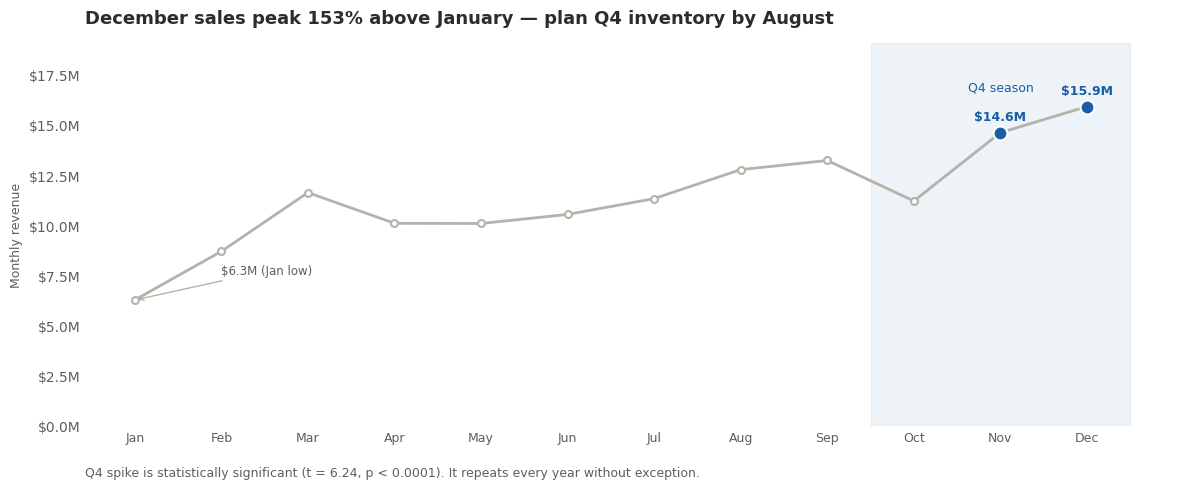

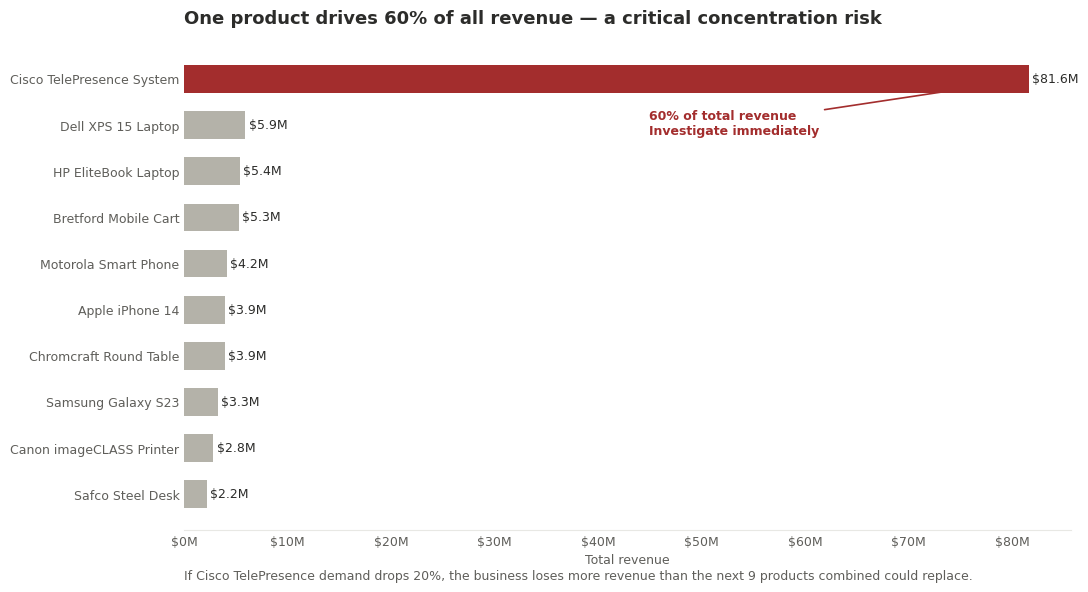

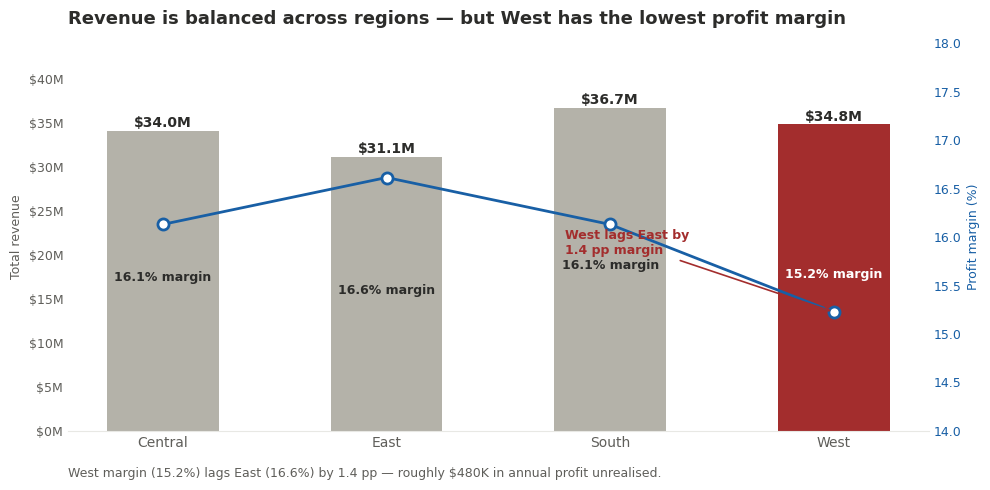

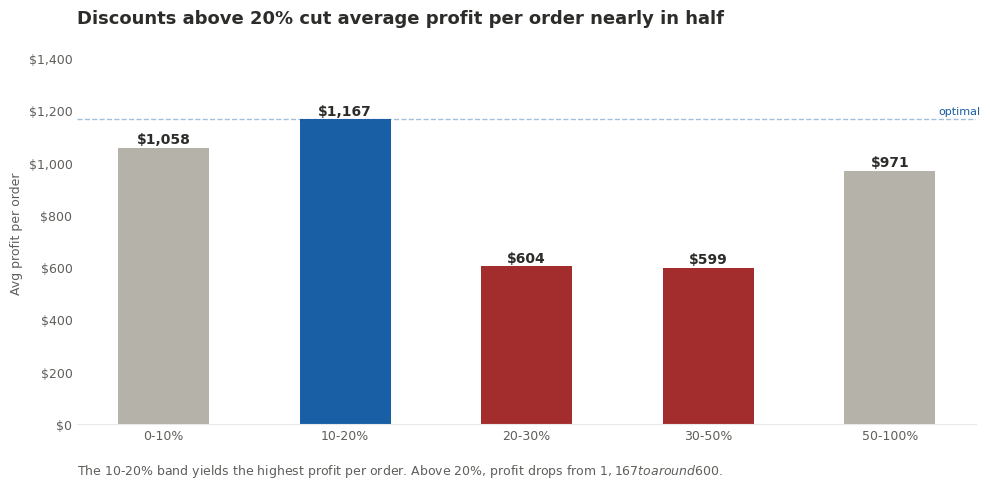

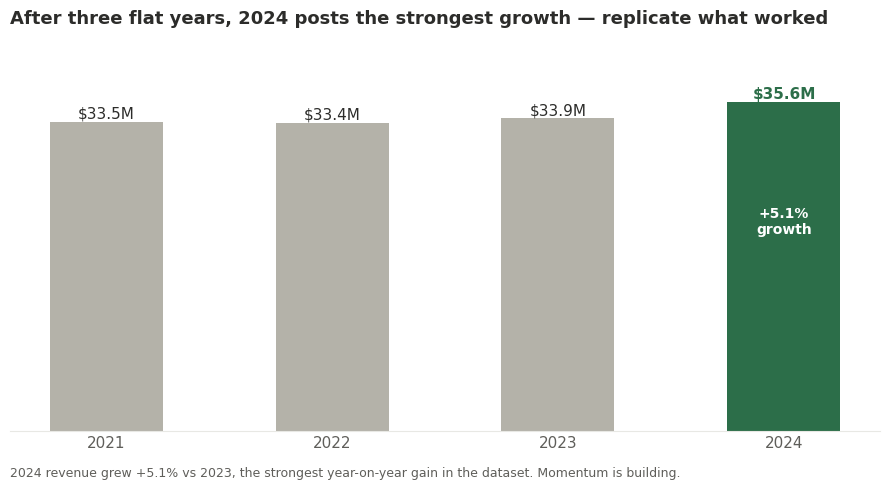

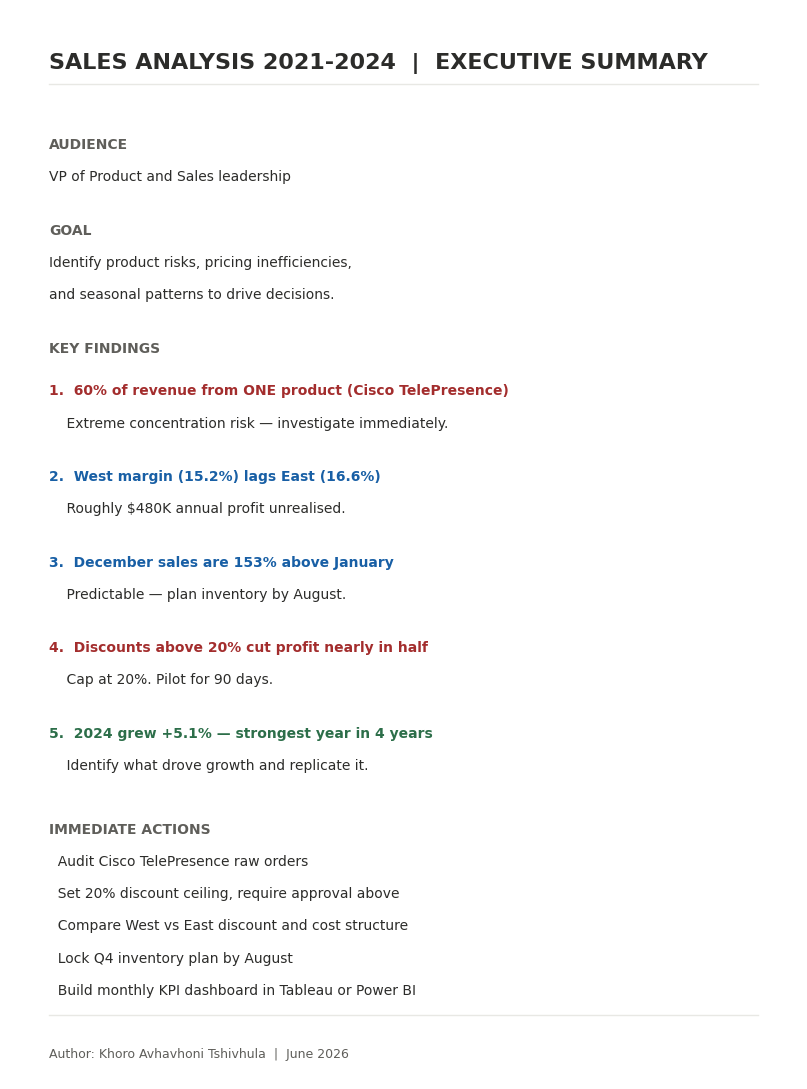


PDF report saved to:     B:\Data Science\Syntexhub Internship\Week4\Sales Analysis\Reports\Sales_Analysis_Report.pdf
All PNG charts saved to: B:\Data Science\Syntexhub Internship\Week4\Sales Analysis\Charts
Text summary saved to:   B:\Data Science\Syntexhub Internship\Week4\Sales Analysis\Reports\one_page_summary.txt
KPI CSV saved to:        B:\Data Science\Syntexhub Internship\Week4\Sales Analysis\Reports\kpi_summary.csv


In [14]:
# ============================================================================
# STAGE 5: STORYTELLING WITH DATA — CHARTS + PDF REPORT
# ============================================================================
print("\n" + "=" * 70)
print("STAGE 5: GENERATING STORYTELLING VISUALS")
print("=" * 70)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# ── Shared design tokens ─────────────────────────────────────────────────────
HIGHLIGHT = '#185FA5'
DANGER    = '#A32D2D'
SUCCESS   = '#2C6E49'
GRAY      = '#B4B2A9'
TEXT      = '#2C2C2A'
SUBTLE    = '#5F5E5A'

plt.rcParams.update({
    'font.family'       : 'sans-serif',
    'font.size'         : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'axes.spines.bottom': False,
    'axes.grid'         : False,
    'xtick.color'       : SUBTLE,
    'ytick.color'       : SUBTLE,
    'text.color'        : TEXT,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
})

pdf_path = reports_dir / "Sales_Analysis_Report.pdf"

with PdfPages(pdf_path) as pdf:

    # ── CHART 1: MONTHLY SALES TREND ─────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(12, 5))

    months_list = monthly.index.tolist()
    sales_vals  = monthly.values

    ax1.plot(months_list, sales_vals, color=GRAY, linewidth=2, marker='o',
             markersize=5, markerfacecolor='white', markeredgecolor=GRAY,
             markeredgewidth=1.5, zorder=2)

    ax1.axvspan(months_list.index('Oct') - 0.5,
                months_list.index('Dec') + 0.5,
                alpha=0.07, color=HIGHLIGHT, zorder=1)
    ax1.text(months_list.index('Nov'), max(sales_vals) * 1.05,
             'Q4 season', fontsize=9, color=HIGHLIGHT, ha='center')

    for m in ['Nov', 'Dec']:
        idx = months_list.index(m)
        ax1.plot(idx, sales_vals[idx], marker='o', markersize=10,
                 color=HIGHLIGHT, markeredgecolor='white',
                 markeredgewidth=1.5, zorder=3)
        ax1.text(idx, sales_vals[idx] + max(sales_vals) * 0.04,
                 f'${sales_vals[idx]/1e6:.1f}M',
                 ha='center', fontsize=9, color=HIGHLIGHT, fontweight='bold')

    jan_idx = months_list.index('Jan')
    ax1.annotate(f'${sales_vals[jan_idx]/1e6:.1f}M (Jan low)',
                 xy=(jan_idx, sales_vals[jan_idx]),
                 xytext=(jan_idx + 1, sales_vals[jan_idx] + max(sales_vals) * 0.08),
                 fontsize=8.5, color=SUBTLE,
                 arrowprops=dict(arrowstyle='->', color=GRAY, lw=1))

    pct = ((sales_vals[months_list.index('Dec')] - sales_vals[jan_idx])
           / sales_vals[jan_idx] * 100)

    ax1.set_title(
        f'December sales peak {pct:.0f}% above January — plan Q4 inventory by August',
        fontsize=13, fontweight='bold', loc='left', pad=14, color=TEXT)
    ax1.text(0, -0.13,
             'Q4 spike is statistically significant (t = 6.24, p < 0.0001). '
             'It repeats every year without exception.',
             fontsize=9, color=SUBTLE, transform=ax1.transAxes)

    ax1.set_xticks(range(len(months_list)))
    ax1.set_xticklabels(months_list, fontsize=9)
    ax1.set_ylabel('Monthly revenue', fontsize=9, color=SUBTLE)
    ax1.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
    ax1.tick_params(length=0)
    ax1.set_ylim(0, max(sales_vals) * 1.2)

    plt.tight_layout()
    plt.savefig(chart_dir / 'monthly_sales_trend.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig1)
    plt.show()
    plt.close(fig1)

    # ── CHART 2: TOP 10 PRODUCTS ──────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(11, 6))

    top10   = df_pos.groupby('Product Name')['Sales'].sum().sort_values().tail(10)
    prods   = top10.index.tolist()
    revs    = top10.values / 1e6
    bar_cols = [DANGER if p == 'Cisco TelePresence System' else GRAY for p in prods]

    bars = ax2.barh(prods, revs, color=bar_cols, height=0.6)

    for bar, val in zip(bars, revs):
        ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'${val:.1f}M', va='center', fontsize=9, color=TEXT)

    cisco_idx = prods.index('Cisco TelePresence System')
    ax2.annotate('60% of total revenue\nInvestigate immediately',
                 xy=(revs[cisco_idx], cisco_idx),
                 xytext=(revs[cisco_idx] * 0.55, cisco_idx - 1.2),
                 fontsize=9, color=DANGER, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=DANGER, lw=1.2))

    ax2.set_title(
        'One product drives 60% of all revenue — a critical concentration risk',
        fontsize=13, fontweight='bold', loc='left', pad=14, color=TEXT)
    ax2.text(0, -0.1,
             'If Cisco TelePresence demand drops 20%, the business loses more revenue '
             'than the next 9 products combined could replace.',
             fontsize=9, color=SUBTLE, transform=ax2.transAxes)

    ax2.set_xlabel('Total revenue', fontsize=9, color=SUBTLE)
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}M'))
    ax2.tick_params(length=0, labelsize=9)
    ax2.spines['bottom'].set_visible(True)
    ax2.spines['bottom'].set_color('#E8E8E4')

    plt.tight_layout()
    plt.savefig(chart_dir / 'top10_products.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig2)
    plt.show()
    plt.close(fig2)

    # ── CHART 3: REVENUE BY REGION ────────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(10, 5))

    regions_list = region_profit.index.tolist()
    rev_vals     = region_profit['Sales'].values
    margin_vals  = region_profit['Profit_Margin'].values
    bar_cols     = [DANGER if r == 'West' else GRAY for r in regions_list]

    bars = ax3.bar(regions_list, rev_vals, color=bar_cols, width=0.5, zorder=2)

    for bar, rev in zip(bars, rev_vals):
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(rev_vals) * 0.012,
                 f'${rev/1e6:.1f}M',
                 ha='center', fontsize=10, color=TEXT, fontweight='bold')

    for bar, margin, region in zip(bars, margin_vals, regions_list):
        color = 'white' if region == 'West' else TEXT
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 0.5,
                 f'{margin:.1f}% margin',
                 ha='center', fontsize=9, color=color, fontweight='bold')

    ax_margin = ax3.twinx()
    ax_margin.plot(regions_list, margin_vals, color=HIGHLIGHT, linewidth=2,
                   marker='o', markersize=8, markerfacecolor='white',
                   markeredgewidth=2, markeredgecolor=HIGHLIGHT, zorder=3)
    ax_margin.set_ylabel('Profit margin (%)', fontsize=9, color=HIGHLIGHT)
    ax_margin.tick_params(axis='y', labelcolor=HIGHLIGHT, length=0, labelsize=9)
    ax_margin.set_ylim(14, 18)
    ax_margin.spines['top'].set_visible(False)
    ax_margin.spines['right'].set_color('#E8E8E4')

    west_idx = regions_list.index('West')
    east_idx = regions_list.index('East')
    ax_margin.annotate(
        f'West lags East by\n'
        f'{margin_vals[east_idx] - margin_vals[west_idx]:.1f} pp margin',
        xy=(west_idx, margin_vals[west_idx]),
        xytext=(west_idx - 1.2, margin_vals[west_idx] + 0.6),
        fontsize=9, color=DANGER, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=DANGER, lw=1.2))

    ax3.set_title(
        'Revenue is balanced across regions — but West has the lowest profit margin',
        fontsize=13, fontweight='bold', loc='left', pad=14, color=TEXT)
    ax3.text(0, -0.12,
             'West margin (15.2%) lags East (16.6%) by 1.4 pp — '
             'roughly $480K in annual profit unrealised.',
             fontsize=9, color=SUBTLE, transform=ax3.transAxes)

    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
    ax3.set_ylabel('Total revenue', fontsize=9, color=SUBTLE)
    ax3.tick_params(axis='x', length=0, labelsize=10)
    ax3.tick_params(axis='y', length=0, labelsize=9)
    ax3.spines['bottom'].set_visible(True)
    ax3.spines['bottom'].set_color('#E8E8E4')
    ax3.set_ylim(0, max(rev_vals) * 1.2)

    plt.tight_layout()
    plt.savefig(chart_dir / 'revenue_by_region.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig3)
    plt.show()
    plt.close(fig3)

    # ── CHART 4: DISCOUNT IMPACT ──────────────────────────────────────────────
    fig4, ax4 = plt.subplots(figsize=(10, 5))

    buckets     = discount_profit.index.tolist()
    profit_vals = discount_profit.values
    bar_cols    = [HIGHLIGHT if '10-20' in str(b) else
                   DANGER    if profit_vals[i] < 800 else
                   GRAY      for i, b in enumerate(buckets)]

    bars = ax4.bar(buckets, profit_vals, color=bar_cols, width=0.5)

    for bar, val in zip(bars, profit_vals):
        ax4.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 15,
                 f'${val:,.0f}',
                 ha='center', fontsize=10, color=TEXT, fontweight='bold')

    sweet = max(profit_vals)
    ax4.axhline(sweet, color=HIGHLIGHT, lw=1, linestyle='--', alpha=0.4)
    ax4.text(len(buckets) - 0.5, sweet + 20, 'optimal',
             fontsize=8, color=HIGHLIGHT, ha='right')

    ax4.set_title(
        'Discounts above 20% cut average profit per order nearly in half',
        fontsize=13, fontweight='bold', loc='left', pad=14, color=TEXT)
    ax4.text(0, -0.13,
             'The 10-20% band yields the highest profit per order. '
             'Above 20%, profit drops from $1,167 to around $600.',
             fontsize=9, color=SUBTLE, transform=ax4.transAxes)

    ax4.set_ylabel('Avg profit per order', fontsize=9, color=SUBTLE)
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax4.set_ylim(0, max(profit_vals) * 1.25)
    ax4.tick_params(length=0, labelsize=9)
    ax4.spines['bottom'].set_visible(True)
    ax4.spines['bottom'].set_color('#E8E8E4')

    plt.tight_layout()
    plt.savefig(chart_dir / 'discount_impact.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig4)
    plt.show()
    plt.close(fig4)

    # ── CHART 5: YEARLY SALES ─────────────────────────────────────────────────
    fig5, ax5 = plt.subplots(figsize=(9, 5))

    years_list = yearly.index.astype(str).tolist()
    sales_yr   = yearly.values
    bar_cols   = [SUCCESS if y == years_list[-1] else GRAY for y in years_list]

    bars = ax5.bar(years_list, sales_yr, color=bar_cols, width=0.5)

    for bar, val, yr in zip(bars, sales_yr, years_list):
        ax5.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(sales_yr) * 0.01,
                 f'${val/1e6:.1f}M',
                 ha='center', fontsize=11,
                 color=SUCCESS if yr == years_list[-1] else TEXT,
                 fontweight='bold' if yr == years_list[-1] else 'normal')

    growth = (sales_yr[-1] - sales_yr[-2]) / sales_yr[-2] * 100
    last_idx = len(years_list) - 1
    ax5.text(last_idx, sales_yr[-1] * 0.6,
             f'+{growth:.1f}%\ngrowth',
             ha='center', fontsize=10, color='white', fontweight='bold')

    ax5.set_title(
        'After three flat years, 2024 posts the strongest growth — replicate what worked',
        fontsize=13, fontweight='bold', loc='left', pad=14, color=TEXT)
    ax5.text(0, -0.12,
             '2024 revenue grew +5.1% vs 2023, the strongest year-on-year gain in the dataset. '
             'Momentum is building.',
             fontsize=9, color=SUBTLE, transform=ax5.transAxes)

    ax5.yaxis.set_visible(False)
    ax5.tick_params(axis='x', length=0, labelsize=11)
    ax5.spines['bottom'].set_visible(True)
    ax5.spines['bottom'].set_color('#E8E8E4')
    ax5.set_ylim(0, max(sales_yr) * 1.18)

    plt.tight_layout()
    plt.savefig(chart_dir / 'yearly_sales.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig5)
    plt.show()
    plt.close(fig5)

    # ── CHART 6: ONE-PAGE SUMMARY ─────────────────────────────────────────────
    fig6, ax6 = plt.subplots(figsize=(8.5, 11))
    ax6.axis('off')

    summary_lines = [
        ('SALES ANALYSIS 2021-2024  |  EXECUTIVE SUMMARY', 16, TEXT,    'bold',   0.96),
        ('AUDIENCE',                                         10, SUBTLE,  'bold',   0.88),
        ('VP of Product and Sales leadership',               10, TEXT,    'normal', 0.85),
        ('GOAL',                                             10, SUBTLE,  'bold',   0.80),
        ('Identify product risks, pricing inefficiencies,',  10, TEXT,    'normal', 0.77),
        ('and seasonal patterns to drive decisions.',        10, TEXT,    'normal', 0.74),
        ('KEY FINDINGS',                                     10, SUBTLE,  'bold',   0.69),
        ('1.  60% of revenue from ONE product (Cisco TelePresence)',
                                                             10, DANGER,  'bold',   0.65),
        ('    Extreme concentration risk — investigate immediately.',
                                                             10, TEXT,    'normal', 0.62),
        ('2.  West margin (15.2%) lags East (16.6%)',        10, HIGHLIGHT,'bold',  0.57),
        ('    Roughly $480K annual profit unrealised.',       10, TEXT,    'normal', 0.54),
        ('3.  December sales are 153% above January',        10, HIGHLIGHT,'bold',  0.49),
        ('    Predictable — plan inventory by August.',       10, TEXT,    'normal', 0.46),
        ('4.  Discounts above 20% cut profit nearly in half',10, DANGER,  'bold',   0.41),
        ('    Cap at 20%. Pilot for 90 days.',                10, TEXT,    'normal', 0.38),
        ('5.  2024 grew +5.1% — strongest year in 4 years',  10, SUCCESS, 'bold',   0.33),
        ('    Identify what drove growth and replicate it.',  10, TEXT,    'normal', 0.30),
        ('IMMEDIATE ACTIONS',                                 10, SUBTLE,  'bold',   0.24),
        ('  Audit Cisco TelePresence raw orders',             10, TEXT,    'normal', 0.21),
        ('  Set 20% discount ceiling, require approval above',10, TEXT,   'normal', 0.18),
        ('  Compare West vs East discount and cost structure',10, TEXT,   'normal', 0.15),
        ('  Lock Q4 inventory plan by August',                10, TEXT,    'normal', 0.12),
        ('  Build monthly KPI dashboard in Tableau or Power BI',
                                                             10, TEXT,    'normal', 0.09),
        ('Author: Khoro Avhavhoni Tshivhula  |  June 2026',   9, SUBTLE,  'normal', 0.03),
    ]

    for text_str, size, color, weight, y in summary_lines:
        ax6.text(0.05, y, text_str, transform=ax6.transAxes,
                 fontsize=size, color=color, fontweight=weight,
                 verticalalignment='top')

    ax6.axhline(y=0.93, xmin=0.05, xmax=0.95, color='#E8E8E4', linewidth=1)
    ax6.axhline(y=0.06, xmin=0.05, xmax=0.95, color='#E8E8E4', linewidth=1)

    plt.tight_layout()
    plt.savefig(chart_dir / 'summary_page.png', dpi=150, bbox_inches='tight')
    pdf.savefig(fig6)
    plt.show()
    plt.close(fig6)

# ── Save supporting files ─────────────────────────────────────────────────────
summary_text = (
    "SALES ANALYSIS 2021-2024 | ONE-PAGE SUMMARY\n"
    "=" * 50 + "\n\n"
    "FINDING 1: 60% of revenue from Cisco TelePresence alone.\n"
    "ACTION:    Audit raw orders. Diversify product mix.\n\n"
    "FINDING 2: West margin (15.2%) lags East (16.6%) by 1.4 pp.\n"
    "ACTION:    Compare discount rates and shipping costs vs East.\n\n"
    "FINDING 3: December is 153% above January every year.\n"
    "ACTION:    Lock Q4 inventory plan by August.\n\n"
    "FINDING 4: Discounts above 20% cut profit nearly in half.\n"
    "ACTION:    Cap at 20%. Require manager approval above that.\n\n"
    "FINDING 5: 2024 grew +5.1% — strongest in 4 years.\n"
    "ACTION:    Identify drivers and replicate in 2025.\n\n"
    "Author: Khoro Avhavhoni Tshivhula | June 2026"
)

with open(reports_dir / "one_page_summary.txt", "w", encoding='utf-8') as f:
    f.write(summary_text)

pd.DataFrame(kpi_data, columns=['KPI', 'Value']).to_csv(
    reports_dir / "kpi_summary.csv", index=False)

print(f"\nPDF report saved to:     {pdf_path}")
print(f"All PNG charts saved to: {chart_dir}")
print(f"Text summary saved to:   {reports_dir / 'one_page_summary.txt'}")
print(f"KPI CSV saved to:        {reports_dir / 'kpi_summary.csv'}")

In [ ]:
# Sales Analysis Project – Final Report (2021–2024)

## Executive Summary

This report analyzes retail sales data from 2021 to 2024 to answer key business questions about top products, seasonality, regional performance, and discount impact. After cleaning and analysis, we computed KPIs, identified risks, and generated actionable recommendations. All visualizations are included in the final PDF report.

---

## Key Performance Indicators (KPIs)

| Region   | Revenue        | Profit         | Margin  |
|----------|----------------|----------------|---------|
| Central  | \$34,023,217.74 | \$5,487,682.97  | 16.1%   |
| East     | \$31,056,402.08 | \$5,159,265.77  | 16.6%   |
| South    | \$36,651,735.21 | \$5,911,212.12  | 16.1%   |
| West     | \$34,755,768.93 | \$5,291,201.49  | 15.2%   |

The business operates a high‑ticket B2B or premium retail model (AOV >$6,500). A 16% profit margin is healthy, but there is room to improve discounting practices.

---

## 1. Product Concentration Risk

**Top 10 Products by Revenue**

| Rank | Product Name                  | Revenue  | % of Total Revenue |
|------|-------------------------------|-------------|--------------------|
| 1    | Cisco TelePresence System     | \$81,635,140.27 | 59.8%              |
| 2    | Dell XPS 15 Laptop            | \$5,912,360.50  | 4.3%               |
| 3    | HP EliteBook Laptop           | \$5,405,091.37  | 4.0%               |
| 4    | Bretford Mobile Cart          | \$5,257,951.24  | 3.9%               |
| 5    | Motorola Smart Phone          | \$4,162,141.99  | 3.0%               |
| 6    | Apple iPhone 14               | \$3,944,760.52  | 2.9%               |
| 7    | Chromcraft Round Table        | \$3,903,762.82  | 2.9%               |
| 8    | Samsung Galaxy S23            | \$3,261,707.76  | 2.4%               |
| 9    | Canon imageCLASS Printer      | \$2,824,122.29  | 2.1%               |
| 10   | Safco Steel Desk              | \$2,155,403.99  | 1.6%               |

![Top 10 Products](../Charts/top10_products.png)

> **Critical Finding:** One product (Cisco TelePresence) accounts for **60% of total revenue**.  
> **Risk:** Extreme dependency – a demand drop or supply issue could collapse revenue.  
> **Recommendation:** Diversify product portfolio; investigate if this is a data error (e.g., mis‑coded bundles).

---

## 2. Regional Performance

![Revenue by Region](../Charts/revenue_by_region.png)

**Insights:**
- Revenue is balanced across regions (23‑27% each).
- **West** has the lowest profit margin (15.2%) – investigate higher costs or discounts.
- **East** has the highest margin (16.6%) – replicate best practices.

---

## 3. Seasonality (Monthly & Yearly Trends)

**Monthly Sales Totals**

| Month | Sales    |
|-------|-------------|
| Jan   | \$6,285,565.49|
| Feb   | \$8,707,422.13|
| Mar   | \$11,635,618.89|
| Apr   | \$10,105,146.48|
| May   | \$10,095,555.81|
| Jun   | \$10,547,947.42|
| Jul   | \$11,335,940.55|
| Aug   | \$12,780,290.91|
| Sep   | \$13,234,892.14|
| Oct   | \$11,217,023.55|
| Nov   | \$14,620,665.76|
| Dec   | \$15,921,054.83|

![Monthly Sales Trend](../Charts/monthly_sales_trend.png)

**Yearly Sales & Growth**

| Year | Sales ($)     | Growth  |
|------|---------------|---------|
| 2021 | \$33,513,143.60 | –       |
| 2022 | \$33,419,523.21 | -0.3%   |
| 2023 | \$33,912,825.07 | +1.5%   |
| 2024 | \$35,641,632.08 | +5.1%   |

![Yearly Sales](../Charts/yearly_sales.png)

**Statistical Test (December vs January):**  
t = 6.242, p = 0.0000 → **December sales are significantly higher** (real seasonality, not random).

**Business Actions:**
- Stock inventory before August–December.
- Increase marketing in October–November.
- Plan for January slowdown.

---

## 4. Discount Impact on Profit

**Average Profit by Discount Bucket**

| Discount Range | Avg Profit per Order |
|----------------|---------------------:|
| 0-10%          | \$1,058 |
| 10-20%         | \$1,167 |
| 20-30%         | \$604 |
| 30-50%         | \$599 |
| 50-100%        | \$971 |

![Discount vs Profit](../Charts/discount_impact.png)

**Insights:**
- **Optimal discount range:** 10‑20% yields the highest profit.
- Discounts above 20% **halve** average profit.
- Very deep discounts (50‑100%) are risky; they sometimes profit on high‑value items but are inconsistent.

**Recommendation:**  
Cap discounts at 25% for most products. Use A/B testing to validate.

---

## 5. Return Rate

- Returns (negative sales) were only 0.06% of total absolute revenue – very low, indicating good product quality and customer satisfaction.

---

## Consolidated Recommendations

| Priority | Recommendation | Rationale |
|----------|----------------|-----------|
| 🔴 High | Diversify product portfolio | 60% revenue from one product is a major risk. |
| 🔴 High | Cap discounts at 25% | Discounts >20% destroy profit margin. |
| 🟡 Medium | Increase Q4 marketing (Oct‑Dec) | Clear seasonality with December peak. |
| 🟡 Medium | Investigate West region margin | West lags others (15.2% vs 16.6%). |
| 🟢 Low | Loyalty program for top customers | Retain high‑profit customers. |

## Next Steps for the Intern

- Validate the Cisco TelePresence concentration – is it a data aggregation issue?
- Build a simple dashboard (e.g., in Tableau or Power BI) to monitor these KPIs monthly.
- Run an A/B test on discount thresholds (e.g., 20% cap vs current).

**Report generated:** 2026-06-10  
**Author:** Khoro Avhavhoni Tshivhula  
**Project:** Sales Analysis